In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cho phép hiển thị đầy đủ các cột/dòng khi in
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Đặt style cho biểu đồ
sns.set_style("whitegrid")

# Đọc file CSV (đường dẫn tùy theo nơi bạn lưu file)
df_raw = pd.read_csv("Bengaluru_House_Data.csv")

# Xem kích thước
print("Shape:", df_raw.shape)

# Xem 5 dòng đầu
df_raw.head()

Shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [5]:
df_raw.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


In [8]:
df = df_raw.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [12]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


In [14]:
def value_count(df):
    for var in df.columns:
        print(df[var].value_counts())
        print("-------------------------------")

value_count(df)

area_type
Super built-up  Area    8790
Built-up  Area          2418
Plot  Area              2025
Carpet  Area              87
Name: count, dtype: int64
-------------------------------
availability
Ready To Move           10581
18-Dec                    307
18-May                    295
18-Apr                    271
18-Aug                    200
19-Dec                    185
18-Jul                    143
18-Mar                    131
18-Jun                     99
20-Dec                     98
21-Dec                     93
19-Mar                     88
18-Feb                     62
18-Nov                     47
18-Jan                     43
18-Sep                     41
19-Jun                     40
18-Oct                     39
19-Jan                     39
19-Jul                     36
17-Dec                     29
20-Jan                     24
17-Oct                     21
19-Sep                     21
22-Jun                     19
19-Aug                     18
21-Jun                 

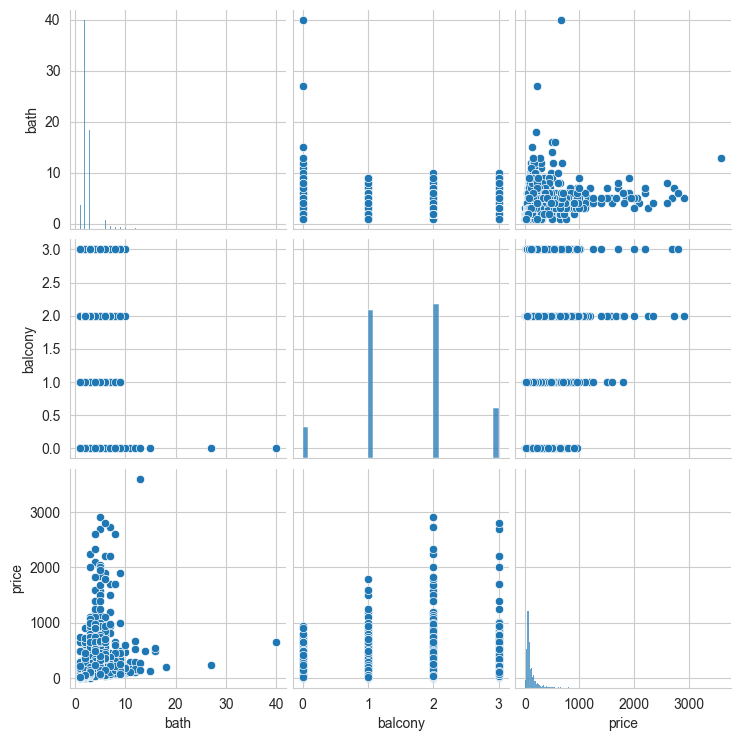

In [16]:
sns.pairplot(df)

<Axes: >

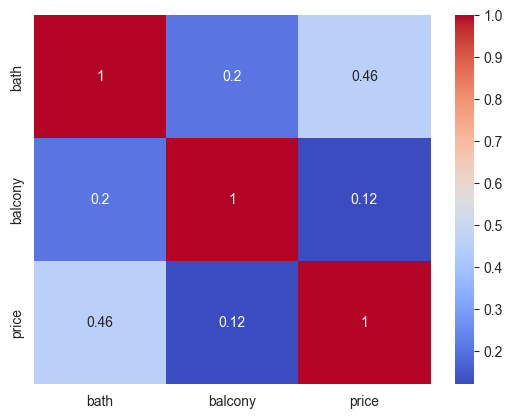

In [18]:
# num_vars = ["bath", "balcony", "price"]
sns.heatmap(df[num_vars].corr(), cmap="coolwarm", annot=True)

In [19]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [20]:
df.isnull().mean() * 100

area_type        0.000000
availability     0.000000
location         0.007508
size             0.120120
society         41.306306
total_sqft       0.000000
bath             0.548048
balcony          4.572072
price            0.000000
dtype: float64

In [21]:
df2 = df.drop('society', axis='columns')
df2.shape

(13320, 8)

In [22]:
df2['balcony'] = df2['balcony'].fillna(df2['balcony'].mean())
df2.isnull().sum()

area_type        0
availability     0
location         1
size            16
total_sqft       0
bath            73
balcony          0
price            0
dtype: int64

In [23]:
df3 = df2.dropna()
df3.shape

(13246, 8)

In [24]:
df3.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [25]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [30]:
df3['total_sqft'].value_counts()

total_sqft
1200                 843
1100                 221
1500                 204
2400                 195
600                  180
1000                 172
1350                 132
1050                 123
1300                 117
1250                 114
900                  112
1400                 108
1800                 104
1150                 101
1600                 100
1140                  91
2000                  82
1450                  70
1650                  69
800                   67
1075                  66
3000                  66
1020                  63
2500                  62
1160                  60
1125                  60
1550                  60
950                   59
1180                  58
1700                  58
1260                  57
1255                  56
1220                  55
1080                  55
1070                  53
700                   52
750                   52
1175                  48
4000                  48
1225          

In [31]:
total_sqft_float = []
for str_val in df3['total_sqft']:
    try:
        total_sqft_float.append(float(str_val))
    except:
        try:
            temp = []
            temp = str_val.split('-')
            total_sqft_float.append((float(temp[0])+float(temp[-1]))/2)
        except:
            total_sqft_float.append(np.nan)

In [32]:
df4 = df3.reset_index(drop=True)

In [33]:
df5 = df4.join(pd.DataFrame({'total_sqft_float':total_sqft_float}))
df5.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0


In [79]:
df5.isnull().sum()

area_type            0
availability         0
location             0
size                 0
total_sqft           0
bath                 0
balcony              0
price                0
total_sqft_float    46
dtype: int64

In [78]:
df6 = df5.dropna()
df.shape

(12514, 12)

In [36]:
df6.info()

<class 'pandas.DataFrame'>
Index: 13200 entries, 0 to 13245
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         13200 non-null  str    
 1   availability      13200 non-null  str    
 2   location          13200 non-null  str    
 3   size              13200 non-null  str    
 4   total_sqft        13200 non-null  str    
 5   bath              13200 non-null  float64
 6   balcony           13200 non-null  float64
 7   price             13200 non-null  float64
 8   total_sqft_float  13200 non-null  float64
dtypes: float64(4), str(5)
memory usage: 1.0 MB


In [37]:
df6['size'].value_counts()

size
2 BHK         5192
3 BHK         4277
4 Bedroom      816
4 BHK          574
3 Bedroom      541
1 BHK          527
2 Bedroom      325
5 Bedroom      293
6 Bedroom      190
1 Bedroom      100
8 Bedroom       83
7 Bedroom       83
5 BHK           56
9 Bedroom       45
6 BHK           30
7 BHK           17
1 RK            13
10 Bedroom      12
9 BHK            7
8 BHK            5
11 BHK           2
11 Bedroom       2
10 BHK           2
27 BHK           1
19 BHK           1
16 BHK           1
43 Bedroom       1
14 BHK           1
12 Bedroom       1
13 BHK           1
18 Bedroom       1
Name: count, dtype: int64

In [39]:
size_int = []
for str_val in df6['size']:
    temp = []
    temp = str_val.split(" ")
    try: 
        size_int.append(int(temp[0]))
    except:
        size_int.append(np.nan)
        print("Noice = ",str_val)

In [40]:
df6 = df6.reset_index(drop=True)

In [81]:
df7 = df6.join(pd.DataFrame({'bhk':size_int}))
df7.shape

(13200, 10)

In [42]:
df7.tail()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk
13195,Built-up Area,Ready To Move,Whitefield,5 Bedroom,3453,4.0,0.000000,231.0,3453.0,5
13196,Super built-up Area,Ready To Move,Richards Town,4 BHK,3600,5.0,1.584376,400.0,3600.0,4
13197,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.000000,60.0,1141.0,2
13198,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,4689,4.0,1.000000,488.0,4689.0,4
13199,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,550,1.0,1.000000,17.0,550.0,1


<Axes: xlabel='total_sqft_float'>

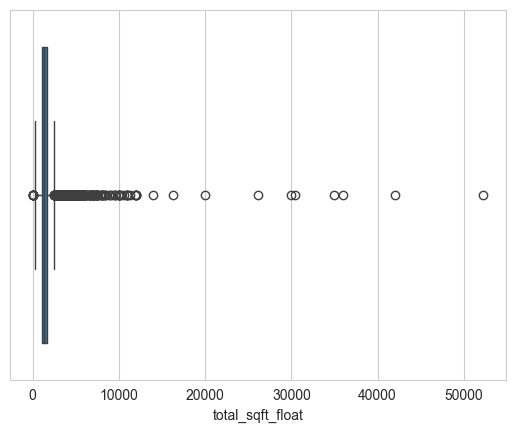

In [43]:
sns.boxplot(x = df7['total_sqft_float'])

In [82]:
df7[df7['total_sqft_float']/df7['bhk'] < 350].head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,1020,6.0,1.584376,370.0,1020.0,6.0
26,Super built-up Area,Ready To Move,Electronic City,2 BHK,660,1.0,1.000000,23.1,660.0,2.0
29,Super built-up Area,Ready To Move,Electronic City,3 BHK,1025,2.0,1.000000,47.0,1025.0,3.0
45,Plot Area,Ready To Move,HSR Layout,8 Bedroom,600,9.0,1.584376,200.0,600.0,8.0
57,Plot Area,Ready To Move,Murugeshpalya,6 Bedroom,1407,4.0,1.000000,150.0,1407.0,6.0


In [45]:
df8 = df7[~(df7['total_sqft_float']/df7['bhk'] < 350)]
df8.shape

(12106, 10)

In [83]:
df8['price_per_sqft'] = df8['price']*100000 / df8['total_sqft_float']
df8.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,1056.0,2.0,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,2600.0,4.0,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00,1440.0,3.0,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,1521.0,3.0,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00,1200.0,2.0,4250.000000


In [84]:
df8.price_per_sqft.describe()

count     12514.000000
mean       6307.367132
std        4160.773691
min         267.829813
25%        4210.762120
50%        5295.073227
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

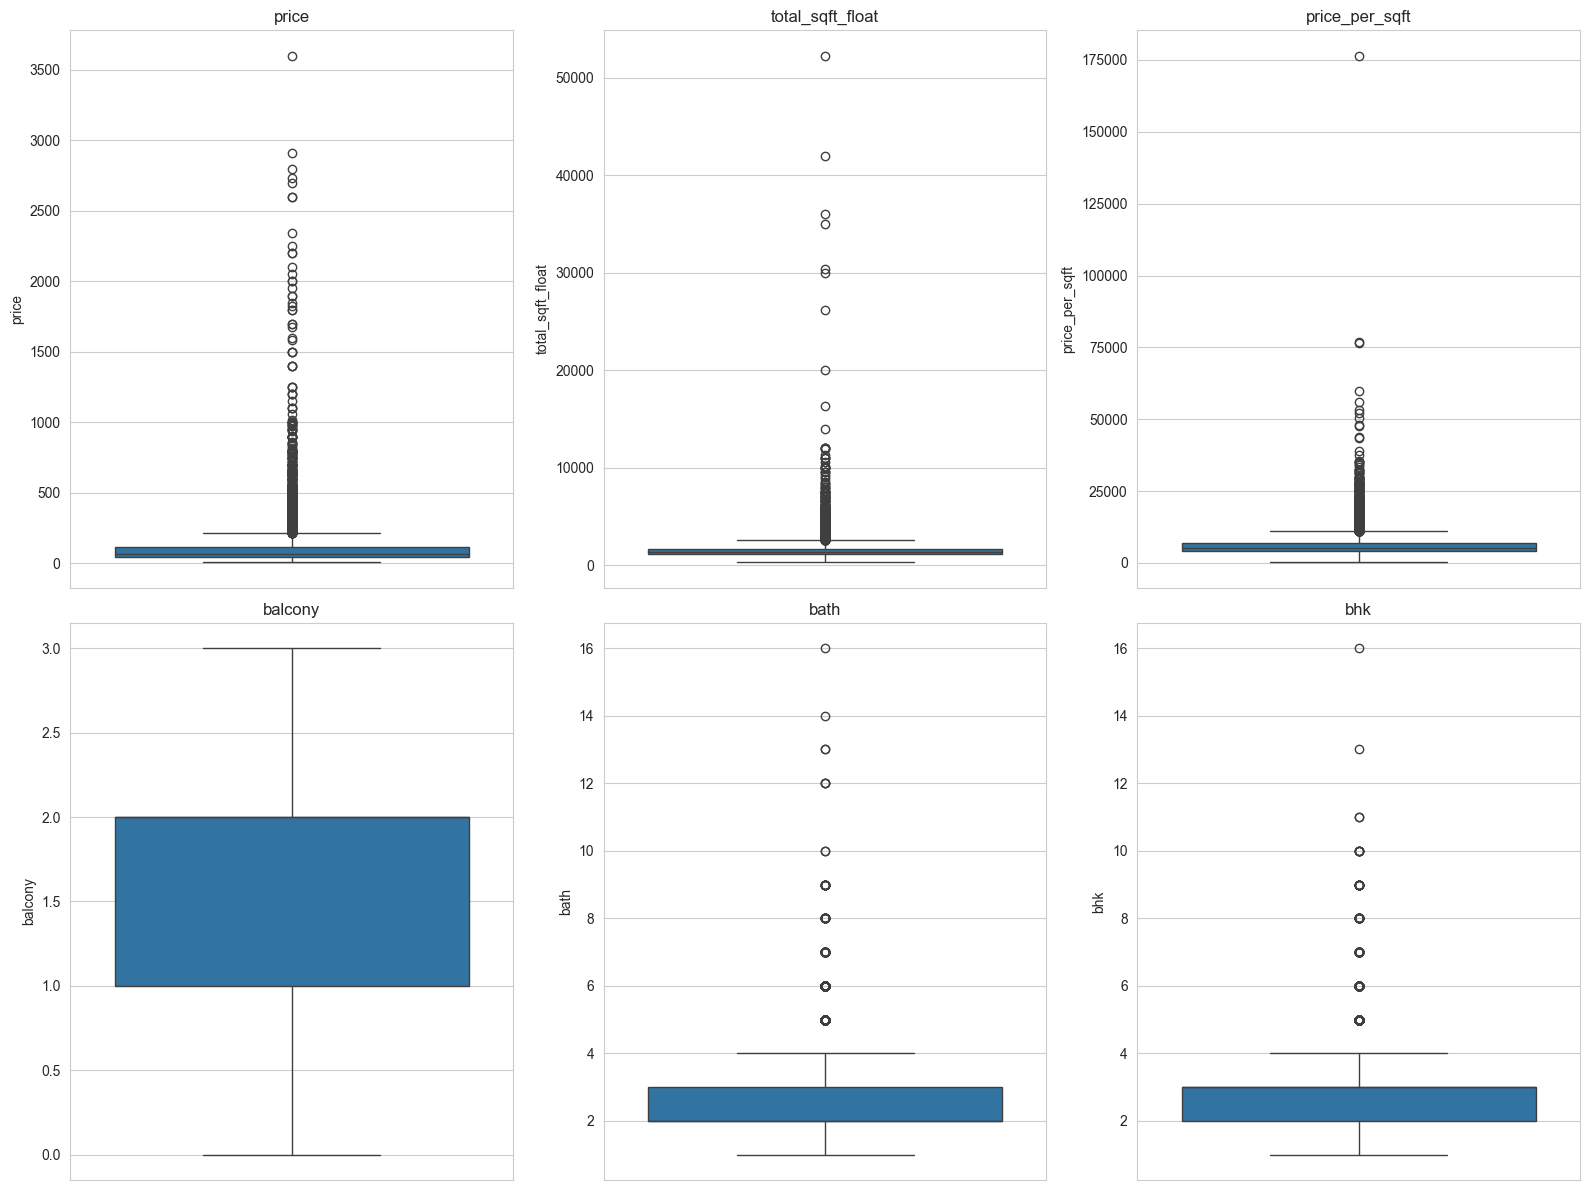

In [85]:
vars = ['price', 'total_sqft_float', 'price_per_sqft', 'balcony', 'bath', 'bhk']
plt.figure(figsize=(16,12))

for i, col in enumerate(vars, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df8[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [86]:
def remove_pps_outliers(df):
    grouped = df.groupby('location')['price_per_sqft']
    mean = grouped.transform('mean')
    std = grouped.transform('std')
    return df[(df['price_per_sqft'] >= mean - std) & (df['price_per_sqft'] <= mean + std)]

df9 = remove_pps_outliers(df8)
df9.shape

(9650, 12)

In [96]:
def remove_bhk_outliers(df):
    exclude_indices = []
    for location in df['location'].unique():
        loc_df = df[df['location'] == location]
        bhk_stats = loc_df.groupby('bhk')['price_per_sqft'].median()
        for bhk in bhk_stats.index:
            if bhk + 1 in bhk_stats:
                if bhk_stats[bhk] > bhk_stats[bhk + 1]:
                    exclude_indices.extend(loc_df[loc_df['bhk'] == bhk].index)
        return df.drop(index=exclude_indices)

df10 = remove_bhk_outliers(df9)
df10.shape

(9647, 12)

In [88]:
df10.bath.unique()

array([ 2.,  5.,  3.,  4.,  1., nan,  8.,  6.,  7.,  9., 14., 16., 12.])

In [89]:
df10[df10.bath > df10.bhk + 2]

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
1078,Plot Area,Ready To Move,BTM 1st Stage,9 Bedroom,Srvasks,3300,14.0,NaN,500.0,3300.0,9.0,15151.515152
2620,Super built-up Area,Ready To Move,Sathya Sai Layout,6 BHK,Prowshi,11338,9.0,1.0,1000.0,11338.0,6.0,8819.897689
7709,Built-up Area,Ready To Move,Chikkabanavar,4 Bedroom,NaN,2460,7.0,2.0,80.0,2460.0,4.0,3252.032520
11366,Built-up Area,Ready To Move,Nagasandra,4 Bedroom,NaN,7000,8.0,NaN,450.0,7000.0,4.0,6428.571429
12103,Super built-up Area,Ready To Move,Thanisandra,3 BHK,Soitya,1806,6.0,2.0,116.0,1806.0,3.0,6423.034330


In [94]:
df11 = df10[df10['bath'] <= df10['bhk'] + 2]
df11.shape

(9591, 12)

In [95]:
df11.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07,1056.0,2.0,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00,2600.0,4.0,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00,1440.0,3.0,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00,1521.0,3.0,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00,1200.0,2.0,4250.000000


In [105]:
columns_to_drop = ['area_type', 'availability', 'location', 'size', 'total_sqft', 'society']
df12 = df.drop(columns=columns_to_drop)
df12.head()

,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,2.0,1.0,39.07,1056.0,2.0,3699.810606
1,5.0,3.0,120.00,2600.0,4.0,4615.384615
2,2.0,3.0,62.00,1440.0,3.0,4305.555556
3,3.0,1.0,95.00,1521.0,3.0,6245.890861
4,2.0,1.0,51.00,1200.0,2.0,4250.000000


In [106]:
# Chọn features và target
X = df12[['total_sqft_float', 'bhk', 'bath', 'balcony']]
y = df12['price']

df12.to_csv("clean_data.csv", index=False)

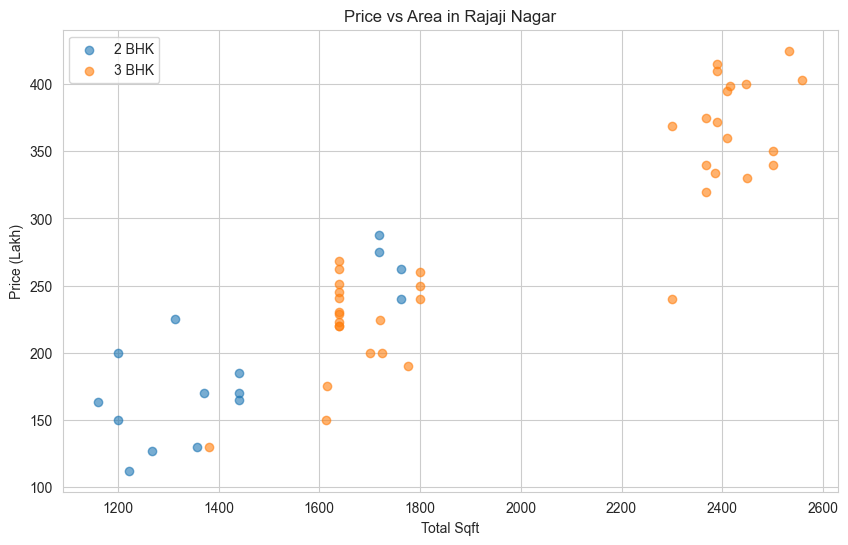

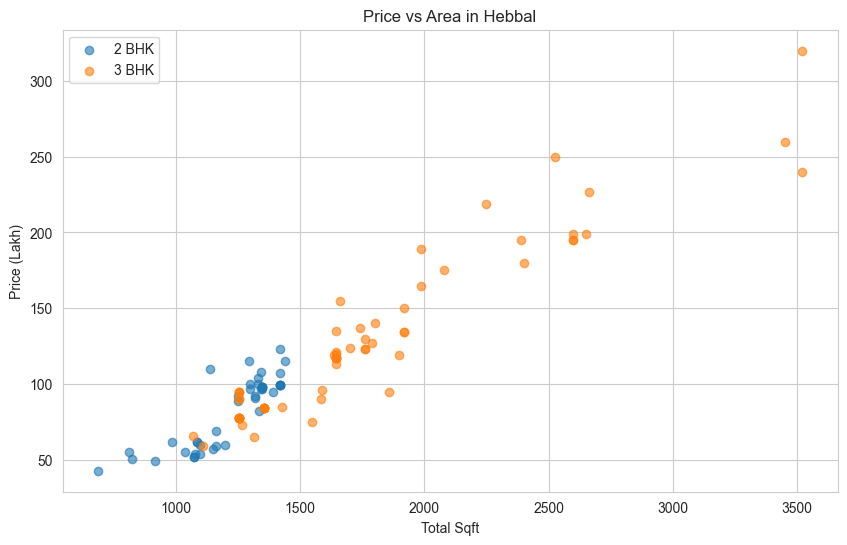

In [107]:
def plot_scatter_chart(df, location):
    subset = df[df['location'] == location]
    plt.figure(figsize=(10,6))
    for bhk in [2,3]:
        data = subset[subset['bhk'] == bhk]
        plt.scatter(data['total_sqft_float'], data['price'], label=f'{bhk} BHK', alpha=0.6)
    plt.xlabel('Total Sqft')
    plt.ylabel('Price (Lakh)')
    plt.title(f'Price vs Area in {location}')
    plt.legend()
    plt.show()

# Ví dụ
plot_scatter_chart(df9, "Rajaji Nagar")
plot_scatter_chart(df9, "Hebbal")

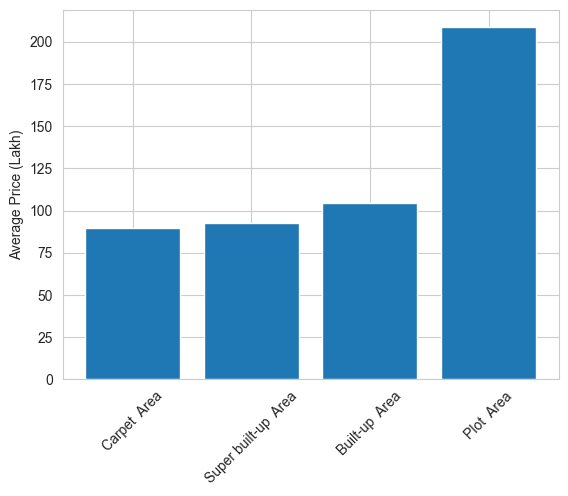

In [104]:
# Nếu còn cột area_type, có thể groupby
price_by_area = df_raw.groupby('area_type')['price'].mean().sort_values()
plt.bar(price_by_area.index, price_by_area.values)
plt.xticks(rotation=45)
plt.ylabel('Average Price (Lakh)')
plt.show()